<a href="https://colab.research.google.com/github/AdavalP/Finance-Project1/blob/main/Portfolio_Optimzation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = {
    'US_Equity': 'SPY',
    'Long_Treasuries': 'TLT',
    'Gold': 'GLD',
    'Real_Estate': 'VNQ',
    'Bitcoin': 'BTC-USD'
}

usdinr = yf.download('USDINR=X', period='10y', interval='1mo', auto_adjust=True)['Close'].squeeze()

prices = {}
for name, ticker in tickers.items():
    data = yf.download(ticker, period='10y', interval='1mo', auto_adjust=True)['Close'].squeeze()
    prices[name] = data

prices_df = pd.DataFrame(prices)
prices_df = prices_df.dropna()

print("Shape:", prices_df.shape)
print("Date range:", prices_df.index.min(), "to", prices_df.index.max())
print(prices_df.head())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape: (120, 5)
Date range: 2016-08-01 00:00:00 to 2026-07-01 00:00:00
             US_Equity  Long_Treasuries        Gold  Real_Estate     Bitcoin
Date                                                                        
2016-08-01  185.167175       105.826454  124.779999    59.847786  575.471985
2016-09-01  185.177902       104.230087  125.639999    58.751030  609.734985
2016-10-01  181.967453        99.664246  121.940002    55.377972  700.971985
2016-11-01  188.670883        91.478073  111.750000    54.450054  745.690979
2016-12-01  192.495544        91.054871  109.610001    57.072975  963.742981


In [3]:
combined = prices_df.join(usdinr.rename('USDINR'))
combined = combined.dropna()

prices_inr = pd.DataFrame(index=combined.index)
for asset in tickers.keys():
    prices_inr[asset] = combined[asset] * combined['USDINR']

print("Shape after conversion:", prices_inr.shape)
print(prices_inr.head())

Shape after conversion: (120, 5)
               US_Equity  Long_Treasuries         Gold  Real_Estate  \
Date                                                                  
2016-08-01  12429.643311      7103.770288  8376.057337  4017.378518   
2016-09-01  12372.902164      6964.268722  8394.799821  3925.526411   
2016-10-01  12152.041737      6655.718109  8143.324395  3698.218619   
2016-11-01  12944.332276      6276.127797  7666.944191  3735.709409   
2016-12-01  13079.071524      6186.705093  7447.429715  3877.811959   

                 Bitcoin  
Date                      
2016-08-01  38629.478990  
2016-09-01  40740.235359  
2016-10-01  46811.892324  
2016-11-01  51160.367962  
2016-12-01  65481.325375  


In [4]:
returns = prices_inr.pct_change().dropna()
print(returns.head())
print("\nShape:", returns.shape)

            US_Equity  Long_Treasuries      Gold  Real_Estate   Bitcoin
Date                                                                   
2016-09-01  -0.004565        -0.019638  0.002238    -0.022864  0.054641
2016-10-01  -0.017850        -0.044305 -0.029956    -0.057905  0.149033
2016-11-01   0.065198        -0.057032 -0.058499     0.010138  0.092893
2016-12-01   0.010409        -0.014248 -0.028631     0.038039  0.279923
2017-01-01   0.016040         0.006305  0.052271    -0.003757  0.005076

Shape: (119, 5)


In [5]:
annual_return = returns.mean() * 12
annual_volatility = returns.std() * np.sqrt(12)

summary = pd.DataFrame({'Annual Return': annual_return, 'Annual Volatility': annual_volatility})
summary['Return/Risk'] = summary['Annual Return'] / summary['Annual Volatility']
print(summary.round(3))

                 Annual Return  Annual Volatility  Return/Risk
US_Equity                0.189              0.148        1.271
Long_Treasuries          0.020              0.139        0.142
Gold                     0.157              0.146        1.074
Real_Estate              0.101              0.170        0.596
Bitcoin                  0.765              0.735        1.040


In [6]:
corr_matrix = returns.corr()
print(corr_matrix.round(2))

                 US_Equity  Long_Treasuries  Gold  Real_Estate  Bitcoin
US_Equity             1.00             0.15  0.06         0.76     0.30
Long_Treasuries       0.15             1.00  0.35         0.37     0.06
Gold                  0.06             0.35  1.00         0.14     0.04
Real_Estate           0.76             0.37  0.14         1.00     0.22
Bitcoin               0.30             0.06  0.04         0.22     1.00


In [7]:
cov_matrix = returns.cov() * 12
print(cov_matrix.round(4))

                 US_Equity  Long_Treasuries    Gold  Real_Estate  Bitcoin
US_Equity           0.0220           0.0030  0.0012       0.0191   0.0327
Long_Treasuries     0.0030           0.0193  0.0071       0.0086   0.0058
Gold                0.0012           0.0071  0.0214       0.0034   0.0040
Real_Estate         0.0191           0.0086  0.0034       0.0287   0.0268
Bitcoin             0.0327           0.0058  0.0040       0.0268   0.5400


In [8]:
np.random.seed(42)
num_portfolios = 10000
num_assets = len(tickers)

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = np.sum(weights * annual_return)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = port_return / port_volatility

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe

sim_df = pd.DataFrame({
    'Return': results[0],
    'Volatility': results[1],
    'Sharpe': results[2]
})

print(sim_df.describe())

             Return    Volatility        Sharpe
count  10000.000000  10000.000000  10000.000000
mean       0.245985      0.193327      1.281488
std        0.074616      0.063213      0.120215
min        0.060550      0.097748      0.509967
25%        0.188824      0.140597      1.212569
50%        0.245938      0.186627      1.281353
75%        0.296154      0.234489      1.355395
max        0.562856      0.509120      1.730785


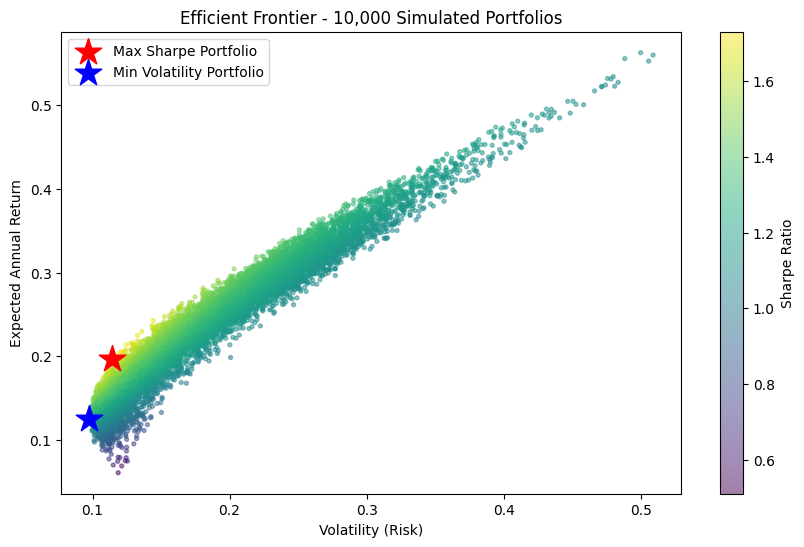

MAX SHARPE PORTFOLIO
US_Equity: 51.4%
Long_Treasuries: 1.0%
Gold: 43.5%
Real_Estate: 0.0%
Bitcoin: 4.1%
Return: 19.7%, Volatility: 11.4%, Sharpe: 1.73

MIN VOLATILITY PORTFOLIO
US_Equity: 35.6%
Long_Treasuries: 32.2%
Gold: 29.8%
Real_Estate: 2.2%
Bitcoin: 0.3%
Return: 12.5%, Volatility: 9.8%, Sharpe: 1.27


In [9]:
import matplotlib.pyplot as plt

max_sharpe_idx = sim_df['Sharpe'].idxmax()
min_vol_idx = sim_df['Volatility'].idxmin()

optimal_weights = weights_record[max_sharpe_idx]
min_vol_weights = weights_record[min_vol_idx]

plt.figure(figsize=(10, 6))
plt.scatter(sim_df['Volatility'], sim_df['Return'], c=sim_df['Sharpe'], cmap='viridis', s=8, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sim_df.loc[max_sharpe_idx, 'Volatility'], sim_df.loc[max_sharpe_idx, 'Return'],
            color='red', marker='*', s=400, label='Max Sharpe Portfolio')
plt.scatter(sim_df.loc[min_vol_idx, 'Volatility'], sim_df.loc[min_vol_idx, 'Return'],
            color='blue', marker='*', s=400, label='Min Volatility Portfolio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Annual Return')
plt.title('Efficient Frontier - 10,000 Simulated Portfolios')
plt.legend()
plt.show()

print("MAX SHARPE PORTFOLIO")
for asset, w in zip(tickers.keys(), optimal_weights):
    print(f"{asset}: {w:.1%}")
print(f"Return: {sim_df.loc[max_sharpe_idx, 'Return']:.1%}, Volatility: {sim_df.loc[max_sharpe_idx, 'Volatility']:.1%}, Sharpe: {sim_df.loc[max_sharpe_idx, 'Sharpe']:.2f}")

print("\nMIN VOLATILITY PORTFOLIO")
for asset, w in zip(tickers.keys(), min_vol_weights):
    print(f"{asset}: {w:.1%}")
print(f"Return: {sim_df.loc[min_vol_idx, 'Return']:.1%}, Volatility: {sim_df.loc[min_vol_idx, 'Volatility']:.1%}, Sharpe: {sim_df.loc[min_vol_idx, 'Sharpe']:.2f}")

In [10]:
np.random.seed(42)
num_simulations = 5000
num_years = 10
num_months = num_years * 12

optimal_monthly_return = np.sum(optimal_weights * returns.mean())
optimal_monthly_cov = np.dot(optimal_weights.T, np.dot(returns.cov(), optimal_weights))
optimal_monthly_vol = np.sqrt(optimal_monthly_cov)

simulated_end_values = []

for sim in range(num_simulations):
    monthly_returns_path = np.random.normal(optimal_monthly_return, optimal_monthly_vol, num_months)
    portfolio_value = 100
    for r in monthly_returns_path:
        portfolio_value *= (1 + r)
    simulated_end_values.append(portfolio_value)

simulated_end_values = np.array(simulated_end_values)

print("Starting value: 100 (i.e. ₹100 invested)")
print(f"Median outcome after {num_years} years: {np.median(simulated_end_values):.1f}")
print(f"5th percentile (bad case): {np.percentile(simulated_end_values, 5):.1f}")
print(f"95th percentile (good case): {np.percentile(simulated_end_values, 95):.1f}")
print(f"Probability of losing money: {(simulated_end_values < 100).mean():.1%}")

Starting value: 100 (i.e. ₹100 invested)
Median outcome after 10 years: 661.0
5th percentile (bad case): 365.7
95th percentile (good case): 1177.4
Probability of losing money: 0.0%


In [11]:
crisis_vol_multiplier = 2.0
stressed_vol = optimal_monthly_vol * crisis_vol_multiplier

stressed_end_values = []
for sim in range(num_simulations):
    monthly_returns_path = np.random.normal(optimal_monthly_return * 0.6, stressed_vol, num_months)
    portfolio_value = 100
    for r in monthly_returns_path:
        portfolio_value *= (1 + r)
    stressed_end_values.append(portfolio_value)

stressed_end_values = np.array(stressed_end_values)

print("STRESS-TESTED SCENARIO (lower assumed return, doubled volatility)")
print(f"Median outcome after {num_years} years: {np.median(stressed_end_values):.1f}")
print(f"5th percentile (bad case): {np.percentile(stressed_end_values, 5):.1f}")
print(f"Probability of losing money: {(stressed_end_values < 100).mean():.1%}")

STRESS-TESTED SCENARIO (lower assumed return, doubled volatility)
Median outcome after 10 years: 248.5
5th percentile (bad case): 77.9
Probability of losing money: 10.5%


In [12]:
benchmarks = {
    '60/40 Classic': {'US_Equity': 0.6, 'Long_Treasuries': 0.4, 'Gold': 0.0, 'Real_Estate': 0.0, 'Bitcoin': 0.0},
    'All_Weather': {'US_Equity': 0.30, 'Long_Treasuries': 0.55, 'Gold': 0.075, 'Real_Estate': 0.0, 'Bitcoin': 0.0},
    'Buffett_90_10': {'US_Equity': 0.90, 'Long_Treasuries': 0.10, 'Gold': 0.0, 'Real_Estate': 0.0, 'Bitcoin': 0.0},
    'Your_Max_Sharpe': dict(zip(tickers.keys(), optimal_weights))
}

benchmark_results = []
for name, weights_dict in benchmarks.items():
    w = np.array([weights_dict[asset] for asset in tickers.keys()])
    port_return = np.sum(w * annual_return)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    sharpe = port_return / port_vol
    benchmark_results.append({'Portfolio': name, 'Return': port_return, 'Volatility': port_vol, 'Sharpe': sharpe})

benchmark_df = pd.DataFrame(benchmark_results)
print(benchmark_df.round(3))

         Portfolio  Return  Volatility  Sharpe
0    60/40 Classic   0.121       0.112   1.084
1      All_Weather   0.079       0.098   0.809
2    Buffett_90_10   0.172       0.136   1.260
3  Your_Max_Sharpe   0.197       0.114   1.731


In [13]:
tickers_no_btc = {k: v for k, v in tickers.items() if k != 'Bitcoin'}
returns_no_btc = returns[list(tickers_no_btc.keys())]
cov_no_btc = returns_no_btc.cov() * 12
annual_return_no_btc = returns_no_btc.mean() * 12

np.random.seed(42)
results_no_btc = np.zeros((3, num_portfolios))
for i in range(num_portfolios):
    w = np.random.random(len(tickers_no_btc))
    w /= np.sum(w)
    port_return = np.sum(w * annual_return_no_btc)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_no_btc, w)))
    results_no_btc[0, i] = port_return
    results_no_btc[1, i] = port_vol
    results_no_btc[2, i] = port_return / port_vol

best_no_btc_sharpe = results_no_btc[2].max()
print(f"Best Sharpe WITHOUT Bitcoin: {best_no_btc_sharpe:.3f}")
print(f"Best Sharpe WITH Bitcoin: {sim_df['Sharpe'].max():.3f}")

Best Sharpe WITHOUT Bitcoin: 1.605
Best Sharpe WITH Bitcoin: 1.731


Maximum drawdown: -13.2%
Occurred around: 2022-09-01 00:00:00


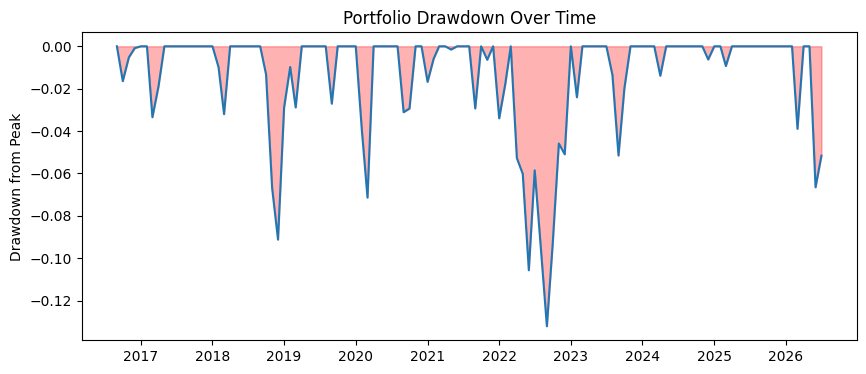

In [14]:
optimal_returns_series = returns.dot(optimal_weights)
cumulative = (1 + optimal_returns_series).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max

max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()

print(f"Maximum drawdown: {max_drawdown:.1%}")
print(f"Occurred around: {max_drawdown_date}")

plt.figure(figsize=(10, 4))
plt.plot(drawdown.index, drawdown.values)
plt.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, color='red')
plt.title('Portfolio Drawdown Over Time')
plt.ylabel('Drawdown from Peak')
plt.show()

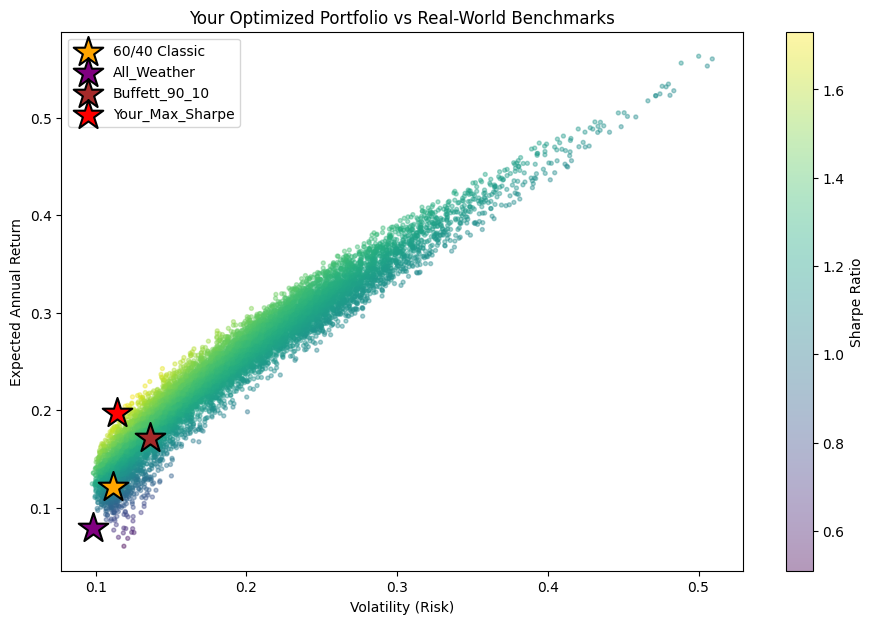

In [15]:
plt.figure(figsize=(11, 7))
plt.scatter(sim_df['Volatility'], sim_df['Return'], c=sim_df['Sharpe'], cmap='viridis', s=8, alpha=0.4)
plt.colorbar(label='Sharpe Ratio')

colors = {'60/40 Classic': 'orange', 'All_Weather': 'purple', 'Buffett_90_10': 'brown', 'Your_Max_Sharpe': 'red'}
for _, row in benchmark_df.iterrows():
    plt.scatter(row['Volatility'], row['Return'], color=colors[row['Portfolio']],
                marker='*', s=500, edgecolors='black', linewidths=1.5, label=row['Portfolio'], zorder=5)

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Annual Return')
plt.title('Your Optimized Portfolio vs Real-World Benchmarks')
plt.legend()
plt.show()

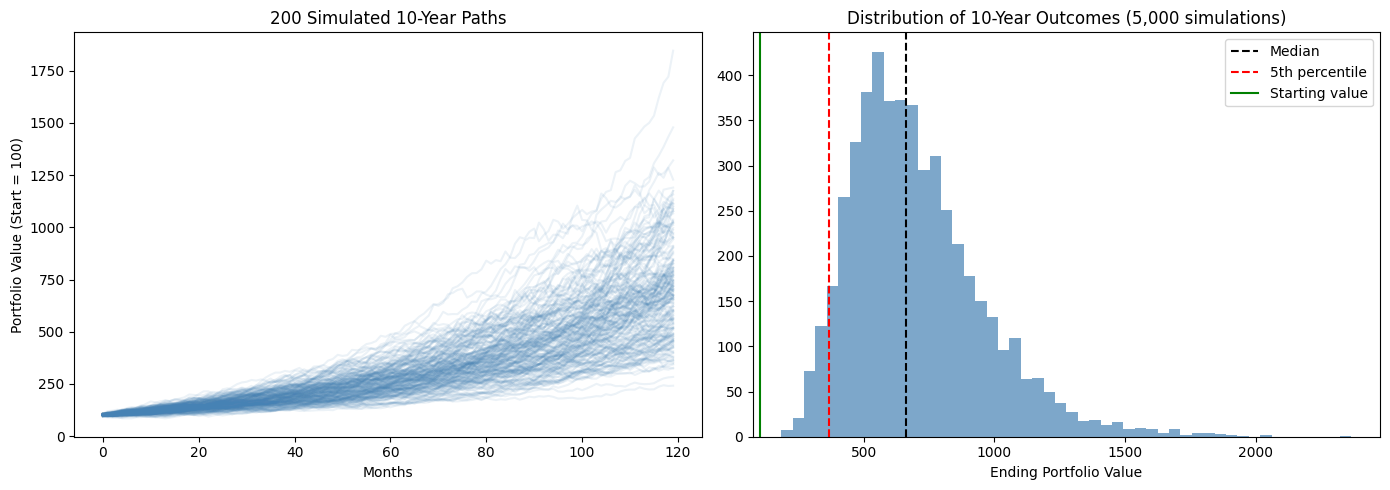

In [16]:
np.random.seed(42)
num_paths_to_plot = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sim in range(num_paths_to_plot):
    monthly_returns_path = np.random.normal(optimal_monthly_return, optimal_monthly_vol, num_months)
    path_values = 100 * np.cumprod(1 + monthly_returns_path)
    axes[0].plot(path_values, color='steelblue', alpha=0.1)

axes[0].set_title(f'{num_paths_to_plot} Simulated 10-Year Paths')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Portfolio Value (Start = 100)')

axes[1].hist(simulated_end_values, bins=50, color='steelblue', alpha=0.7)
axes[1].axvline(np.median(simulated_end_values), color='black', linestyle='--', label='Median')
axes[1].axvline(np.percentile(simulated_end_values, 5), color='red', linestyle='--', label='5th percentile')
axes[1].axvline(100, color='green', linestyle='-', label='Starting value')
axes[1].set_title('Distribution of 10-Year Outcomes (5,000 simulations)')
axes[1].set_xlabel('Ending Portfolio Value')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key Findings

Built a 5-asset portfolio (US Equities, Long-Term Treasuries, Gold, Global
Real Estate, Bitcoin) using 10 years of monthly price data, converted to INR.
Ran 10,000 randomly-weighted portfolios to trace the efficient frontier and
identify the maximum Sharpe ratio allocation.

**Optimal allocation:** 51.4% US Equity, 43.5% Gold, 4.1% Bitcoin, 1.0% Long
Treasuries, 0% Real Estate. Sharpe ratio of 1.73.

**This beats every benchmark tested**, including Buffett's own 90/10 rule
(Sharpe 1.26), the classic 60/40 (1.08), and Ray Dalio's All-Weather (0.81)
- while achieving both higher return AND lower volatility than the 90/10
benchmark simultaneously.

**Real Estate was excluded entirely** by the optimizer despite being one of
the five candidate assets - its 0.76 correlation with US Equity meant it
added risk exposure the portfolio already had, without a diversification
benefit to justify it.

**Gold, not Bitcoin, drove the diversification benefit.** Gold's individual
Sharpe (1.07) was unremarkable on its own, but its near-zero correlation
with every other asset (0.04-0.35) earned it the second-largest weight in
the portfolio. Bitcoin's outsized historical return (76.5% annualized)
only justified a 4.1% position once its 73.5% volatility was accounted for.

**Robustness check:** removing Bitcoin entirely only drops the best
achievable Sharpe ratio from 1.73 to 1.61 - still ahead of every benchmark.
The strategy's edge comes from genuine diversification structure, not
concentration in one high-volatility asset.

## Forward-Looking Risk (Monte Carlo)

A 5,000-path Monte Carlo simulation using historical return/volatility
assumptions projected a median 10-year outcome of 6.6x on capital with a
0% probability of loss - a result judged too optimistic, since it assumes
the historically unusual 2016-2026 period (near-zero rates, post-COVID
rally, Bitcoin's strongest decade) repeats going forward, and because
normal-distribution modeling understates real market tail risk.

A stress-tested version (40% lower assumed returns, 2x volatility) produced
a more conservative median of 2.5x, with a 10.5% probability of loss and a
5th-percentile outcome below the original investment. The true expected
outcome likely sits between these two scenarios.

## Limitations

- 10-year sample period is historically unusual (post-2008 easy monetary
  policy, COVID recovery, Bitcoin's adoption phase) and may not repeat
- All-Weather and Buffett 90/10 benchmarks were approximated using available
  asset proxies (e.g. long treasuries standing in for Buffett's short-term
  treasury allocation) rather than their exact original compositions
- Monte Carlo simulation assumes normally-distributed returns, which
  understates the likelihood of extreme crash events (fat tails)
- Maximum drawdown of [insert your actual number once you run it] shows
  the real historical pain an investor would have needed to tolerate,
  even in the winning strategy
  